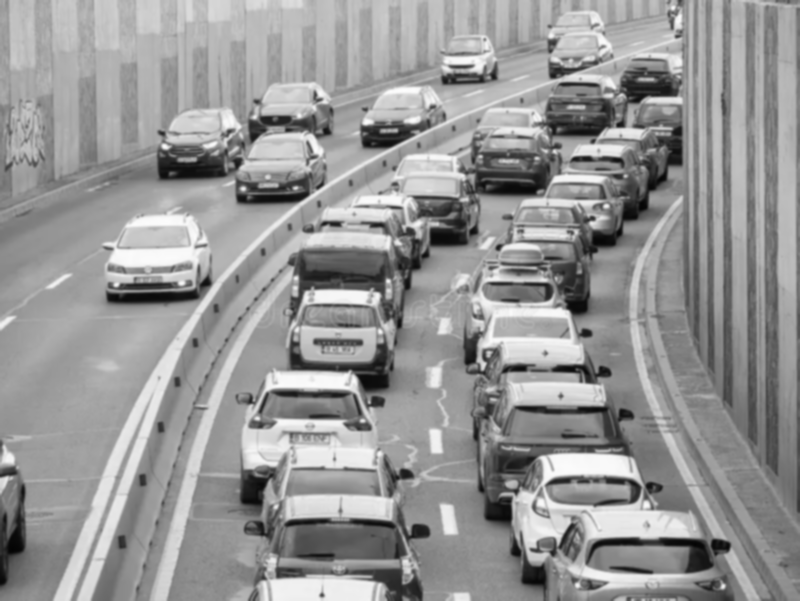

In [4]:
import cv2
from google.colab.patches import cv2_imshow

# Read image
img = cv2.imread("/content/image2222.webp")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Noise removal using Gaussian Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

cv2_imshow(blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [5]:
from skimage.feature import hog

features, hog_image = hog(blur,
                         orientations=9,
                         pixels_per_cell=(8,8),
                         cells_per_block=(2,2),
                         visualize=True)

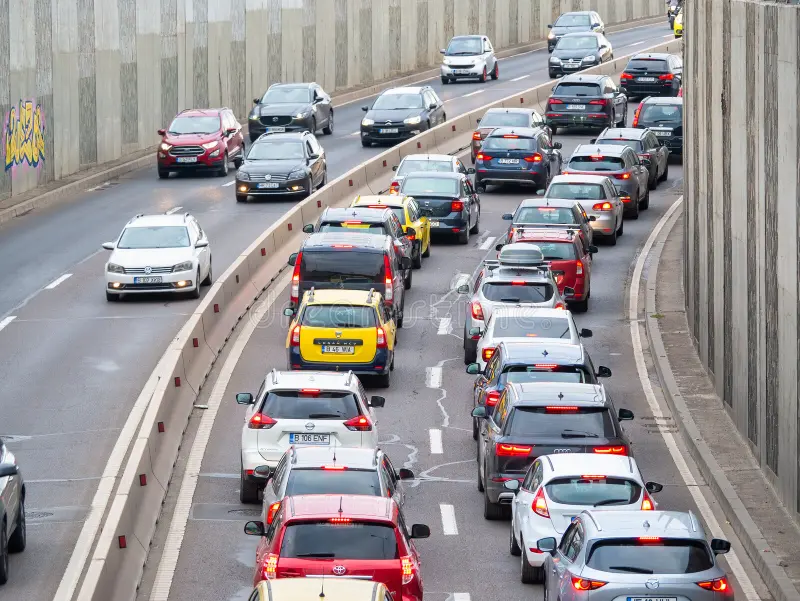

In [7]:
step_size = 32
window_size = (64, 64)

for y in range(0, gray.shape[0] - window_size[1], step_size):
    for x in range(0, gray.shape[1] - window_size[0], step_size):
        window = gray[y:y+64, x:x+64]

        features = hog(window, orientations=9,
                       pixels_per_cell=(8,8),
                       cells_per_block=(2,2))

        # Dummy condition (replace with classifier)
        if features.mean() > 0.2:
            cv2.rectangle(img, (x,y), (x+64,y+64), (0,255,0), 2)

cv2_imshow(img)


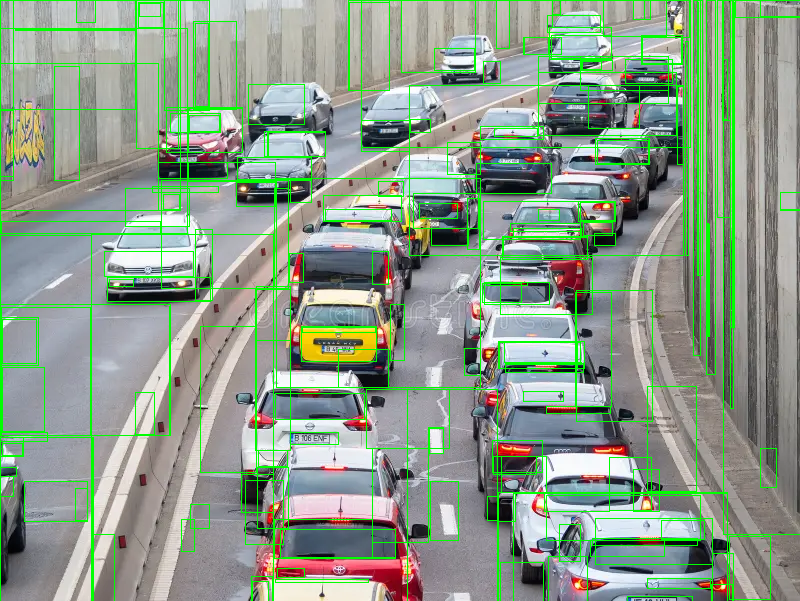

In [9]:
import cv2
from google.colab.patches import cv2_imshow

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img)
ss.switchToSelectiveSearchFast()

rects = ss.process()

for (x, y, w, h) in rects[:100]:  # limit for display
    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 1)

cv2_imshow(img)

--2026-04-20 05:35:17--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3030::ac43:b9c7, ...
Connecting to pjreddie.com (pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-04-20 05:35:17--  https://data.pjreddie.com/files/yolov3.weights
Resolving data.pjreddie.com (data.pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3030::ac43:b9c7, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights.3’

yolov3.weights.3    100%[===================>] 236.52M  87.9MB/s    in 2.7s    

2026-04-20 05:35:20 (87.9 MB/s) - ‘yolov3.weights.3’ saved [248007048/248007048]

--2026-04-20 05:35:20--  https://github.com/pjreddie/d

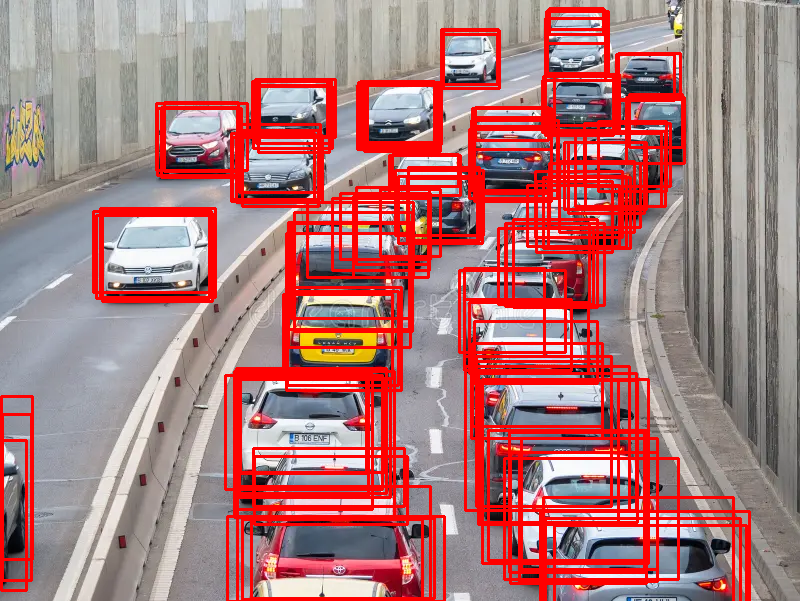

In [15]:
import cv2
from google.colab.patches import cv2_imshow

# You need to download 'yolov3.weights' and 'yolov3.cfg' files first.
# For example, you can use !wget commands to download them.
!wget https://pjreddie.com/media/files/yolov3.weights
!wget https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true -O yolov3.cfg
# Also make sure to download or upload the image file, e.g., 'traffic.jpg'
# !wget https://pjreddie.com/media/files/traffic.jpg # Uncomment this line if you want to use a sample traffic image

net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

img = cv2.imread("/content/image2222.webp") # Make sure the image path is correct

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image '/content/image2222.webp'. Please ensure the file exists.")
else:
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (416,416), swapRB=True)

    net.setInput(blob)
    layer_names = net.getUnconnectedOutLayersNames()
    outputs = net.forward(layer_names)

    h, w = img.shape[:2]

    for output in outputs:
        for detection in output:
            scores = detection[5:]
            class_id = scores.argmax()
            confidence = scores[class_id]

            if confidence > 0.5:
                cx, cy, bw, bh = detection[0:4] * [w, h, w, h]
                x = int(cx - bw/2)
                y = int(cy - bh/2)

                cv2.rectangle(img, (x,y), (int(cx+bw/2), int(cy+bh/2)), (0,0,255), 2)

    cv2_imshow(img)
